In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = sns.load_dataset("titanic")
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df.drop(columns=["deck"],inplace=True)
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
df["age"] = df["age"].fillna(df['age'].median())
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [7]:
df = df.dropna(subset=['embarked'])
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [8]:
df = pd.get_dummies(df, columns=["sex","embarked"],drop_first=True, dtype =int)
df.head(5)

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,1,0,1
1,1,1,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,0,0,0
2,1,3,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,0,0,1
3,1,1,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,0,0,1
4,0,3,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,1,0,1


In [9]:
df = df.drop(columns=['class', 'who', 'adult_male', 'embark_town', 'alive', 'alone'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    889 non-null    int64  
 1   pclass      889 non-null    int64  
 2   age         889 non-null    float64
 3   sibsp       889 non-null    int64  
 4   parch       889 non-null    int64  
 5   fare        889 non-null    float64
 6   sex_male    889 non-null    int64  
 7   embarked_Q  889 non-null    int64  
 8   embarked_S  889 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 69.5 KB


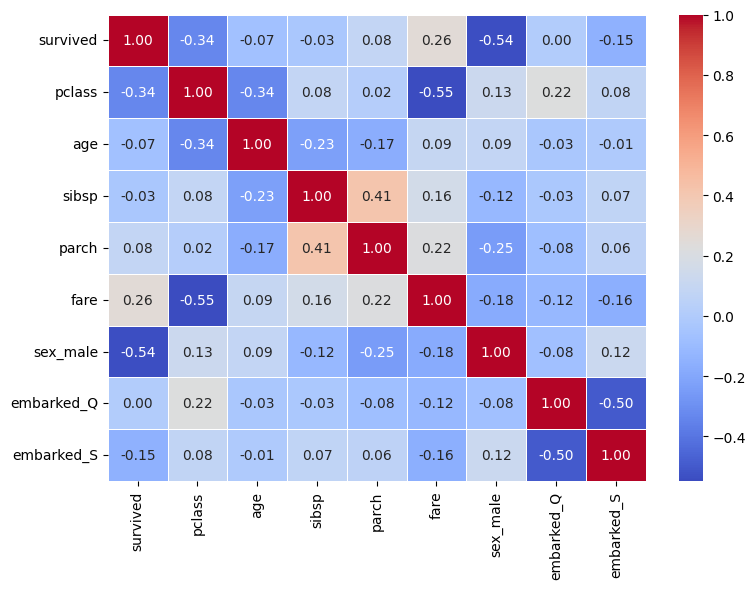

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split
X = df.drop(columns="survived")
y = df["survived"]
# 20 percentage for train, #meaning of life = 42
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20 , random_state=42)
m1 = X_train.shape[0]
m2 = X_test.shape[0]
m3 = y_train.shape[0]
m4 = y_test.shape[0]
m1,m2,m3,m4

(711, 178, 711, 178)

In [34]:
from sklearn.preprocessing import StandardScaler

#Z_score standartization
scaler = StandardScaler()

# Model kopya çekmesin diye kuralı SADECE eğitim verisinden öğren (fit) ve dönüştür (transform)
X_train_scaled = scaler.fit_transform(X_train)

# Öğrenilen o kuralı test verisine doğrudan uygula (Burada asla fit YAPILMAZ)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.linear_model import LogisticRegression
# Modelimizi oluşturuyoruz (L2 Regularization/Ceza sistemi varsayılan olarak aktiftir)
logistic_model = LogisticRegression(random_state=42)

###!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!###
# Gradient Descent,regularization,sigmoid burada çalışır. Hatalara bakılarak en ideal katsayılar (ağırlıklar) bulunur.logistic_model.fit(X_train_scaled,y_train)
logistic_model.fit(X_train_scaled, y_train)

# Öğrenme bitmiştir. Bulunan katsayılarla Z denklemi çözülür, Sigmoid fonksiyonundan geçirilip 0 veya 1 kararı verilir.
y_prediction =  logistic_model.predict(X_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score

# Sadece Doğruluk Oranını (Accuracy) hesaplıyoruz
acc = accuracy_score(y_test, y_prediction)

# Sonucu okunabilir bir yüzde formatında ekrana yazdırıyoruz
print(f"Modelin Başarı Oranı: %{basari_orani * 100:.2f}")

Modelin Başarı Oranı: %76.97
